# Authoring a model as equations: a bivariate UC output-gap model on US data

This notebook is the S7 end-state walkthrough. Nothing in it exists as a
hand-written family in the codebase: the model below is **written as
equations** in the notebook, the framework compiles it into exactly the
declaration surface a hand-written family provides (named state metadata,
system-matrix builders, a rendered Stan program, prior table, mirror
declaration, output modules, a validation suite), and the authored model
then flows through the **entire existing machinery unchanged** -- `mtk.fit`
with the automatic Stan-vs-Python mirror check, the immutable hash-identified
run store, the simulation smoother, the generic IRF/HD/fan engine, the
report, `mtk.sweep`, and `mtk validate`.

**The model.** Output `y` (100·ln real GDP) is a trend `ystar` plus a cycle
`gap`; the trend grows at a random-walk rate `g` (annualized; the quarterly
increment is `g/4`); the cycle is an AR(2) whose innovation -- the demand
shock -- carries stochastic volatility; inflation `pi` follows an
accelerationist Phillips curve in its own lags with the lagged gap as the
driving term:

    y     = ystar + gap + e_y
    pi    = b_pi*pi[-1] + (1 - b_pi)*mean(pi[-2], pi[-3], pi[-4]) + b_y*gap[-1] + e_pi
    ystar = ystar[-1] + 0.25*g + eta_ystar
    g     = g[-1] + eta_g
    gap   = a1*gap[-1] + a2*gap[-2] + eta_gap        (eta_gap ~ N(0, exp(h_t)), h a random walk)

Unlike lw_sv (where the gap dynamics are hidden in the measurement equation
by the conditionally-linear trick and `r*` is a state), the gap here is a
**state** with parameter-dependent transition dynamics, and there is no
real-rate block -- a model the codebase does not contain.

Data: the in-repo `examples/us_lw_sv/data/us_quarterly.csv` (US quarterly
GDP and core PCE inflation, 1960Q1--2019Q4). This notebook samples (4 chains x 500/500 per fit, three fits with the
sweep: roughly an hour on four cores).

In [1]:
from pathlib import Path
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from macrotoolkit import api as mtk
from macrotoolkit import authoring as au
from macrotoolkit.run import REPO_ROOT as REPO   # never walk parent directories from a tmp dir (HANDOFF warning)

DATA = REPO / "examples" / "us_lw_sv" / "data" / "us_quarterly.csv"
df = pd.read_csv(DATA, parse_dates=["date"])
df = df[df["date"] <= "2019-12-31"].reset_index(drop=True)
df.tail(3)

,date,lgdp100,core_pce_ann,real_rate
235,2018-10-01,991.861623,1.868901,0.322994
236,2019-01-01,992.484001,1.601417,0.747146
237,2019-04-01,993.315679,1.685094,0.854148


## 1. Write the model down

Series names are the economist's own; `x[-k]` is a lag; `mean(...)` averages
lags of one observable into one regressor; a shock is either a constant scale
(`au.shock("sigma_x")`, pointing at a half-normal parameter) or an SV block
(`au.sv(...)`, the established non-centered log-variance random walk; `h` is
log-variance, so the shock's standard deviation is `exp(h/2)`). Every state
gets an explicit initial condition -- the KF takes `(xi00, P00)` explicitly,
there is no diffuse hack. Priors come from the menu the existing templates
stamp: normal (optionally truncated through the Stan constraint), half-normal,
beta.

Anything outside the linear-Gaussian scope fails loudly with a message naming
the limitation (try `y = ystar*gap + e_y`).

In [2]:
model = au.Model(
    "uc_gap_sv",
    observables=["y", "pi"],
    measurement=[
        "y = ystar + gap + e_y",
        "pi = b_pi*pi[-1] + (1 - b_pi)*mean(pi[-2], pi[-3], pi[-4]) + b_y*gap[-1] + e_pi",
    ],
    transition=[
        "ystar = ystar[-1] + 0.25*g + eta_ystar",   # g annualized: quarterly increment g/4
        "g = g[-1] + eta_g",
        "gap = a1*gap[-1] + a2*gap[-2] + eta_gap",
    ],
    parameters={
        "a1": au.normal(1.2, 0.3),
        "a2": au.normal(-0.4, 0.3),
        "b_pi": au.beta(8.0, 2.0),
        "b_y": au.normal(0.15, 0.1, lower=0.0),
        "sigma_ystar": au.half_normal(0.3),
        "sigma_g": au.half_normal(0.03),        # pile-up control, as in lw_sv (documented identification work)
        "sigma_y": au.half_normal(0.2),         # measurement noise on output
        "sigma_pi": au.half_normal(1.0),
    },
    shocks={
        "eta_ystar": au.shock("sigma_ystar"),
        "eta_g": au.shock("sigma_g"),
        "eta_gap": au.sv(sigma_h=0.2, h0_sd=1.0, mu_h0=au.log_var_diff("y", 0.5)),   # the demand shock, with SV
        "e_y": au.shock("sigma_y"),
        "e_pi": au.shock("sigma_pi"),
    },
    initial_state={
        "ystar": au.init(au.first_obs("y"), 2.0),
        "g": au.init(3.0, 1.0),
        "gap": au.init(0.0, 2.0),
    },
)
print(model.describe())

authored model 'uc_gap_sv'
  observables: ['y', 'pi']   exogenous: []
  state vector: ystar, g, gap, gap[-1]
  state shocks: ['eta_ystar', 'eta_g', 'eta_gap']   measurement shocks: ['e_y', 'e_pi']
  SV shocks: ['eta_gap']
  regressor columns (feedback map): ['pi[-1]', 'mean(pi[-2], pi[-3], pi[-4])']   pre-sample lag rows: 4


The compiler derived the state vector mechanically: `gap` needs two slots
(the AR(2) and the Phillips curve's `gap[-1]`), `ystar` and `g` one each;
the four inflation lags in the Phillips curve became the regressor
(feedback-map) columns and imply four pre-sample rows. The compiled
`StateSpaceMeta` is the same object every hand-written family declares, and
the system matrices are built from the coefficient expressions as written
(`F` carries `a1`, `a2` -- a parameter-dependent transition).

In [3]:
compiled = model.compiled()
print(compiled.meta.state_labels)
print("state shocks:", compiled.meta.state_shocks, "| measurement shocks:", compiled.meta.measurement_shocks)
print("feedback map:", compiled.meta.feedback_map)
F, Q, A, Z, R = compiled.build_matrices({"a1": 1.2, "a2": -0.4, "b_pi": 0.8, "b_y": 0.15, "sigma_ystar": 0.3,
                                          "sigma_g": 0.03, "sigma_y": 0.2, "sigma_pi": 1.0},
                                         h={"eta_gap": np.full(3, 2 * np.log(0.5))}, T=3)
print("F =\n", F)
print("Z =\n", Z)
print("Q_t[0] diagonal =", np.diag(Q[0]))

(('ystar', 0), ('g', 0), ('gap', 0), ('gap', -1))
state shocks: ('eta_ystar', 'eta_g', 'eta_gap') | measurement shocks: ('e_y', 'e_pi')
feedback map: (ObsLag(name='pi', lag=1), ObsLagMean(name='pi', lags=(2, 3, 4)))
F =
 [[ 1.    0.25  0.    0.  ]
 [ 0.    1.    0.    0.  ]
 [ 0.    0.    1.2  -0.4 ]
 [ 0.    0.    1.    0.  ]]
Z =
 [[1.   0.   1.   0.  ]
 [0.   0.   0.   0.15]]
Q_t[0] diagonal = [0.09005625 0.0009     0.25       0.        ]


## 2. The spec, the fit, the mirror check

The authored model is **data**: `mtk.spec("authored", options=model, ...)`
builds the same `RunSpec` a YAML file would (the equations are canonicalized
and enter the run-identity hash), so the run is immutable and reproducible
like any other. Before sampling, the exact rendered Stan program's
Kalman-filter log-likelihood is cross-checked against the Python mirror at 5
prior draws (G1's 1e-8 gate) -- automatically, for an authored model as for a
hand-written one.

In [4]:
spec = mtk.spec(
    "authored",
    options=model,
    data={"file": "data/us_quarterly.csv", "date_column": "date",
          "mapping": {"y": "lgdp100", "pi": "core_pce_ann"}, "sample": {"start": "1960Q1", "end": "2019Q4"}},
    sampler={"chains": 4, "warmup": 500, "sampling": 500, "adapt_delta": 0.95, "max_treedepth": 12, "seed": 20260813},
    outputs={"smoother_draws": {"thin": 4}, "horizon": 12, "irf_horizon": 20},
)
print(spec.to_estimation_yaml()[:900], "...")

data:
  date_column: date
  file: data/us_quarterly.csv
  mapping:
    pi: core_pce_ann
    y: lgdp100
  sample:
    end: 2019Q4
    start: 1960Q1
model:
  family: authored
  options:
    equations:
      measurement:
      - y = ystar + gap + e_y
      - pi = b_pi*pi[-1] + (1.0 - b_pi)*mean(pi[-2], pi[-3], pi[-4]) + b_y*gap[-1]
        + e_pi
      transition:
      - ystar = ystar[-1] + 0.25*g + eta_ystar
      - g = g[-1] + eta_g
      - gap = a1*gap[-1] + a2*gap[-2] + eta_gap
    exogenous: []
    family: authored
    forecast_rules: {}
    initial_state:
      g:
        mean: 3.0
        sd: 1.0
      gap:
        mean: 0.0
        sd: 2.0
      ystar:
        mean:
          first_obs: y
        sd: 2.0
    name: uc_gap_sv
    observables:
    - y
    - pi
    parameters:
      a1:
        dist: normal
        lower: null
        mu: 1.2
        sd: 0.3
        upper: null
      a ...


In [5]:
run = mtk.fit(spec, base_dir=DATA.parents[1])
print("hash:", run.hash, "| verdict:", run.verdict)
print("reasons:", run.diagnostics["reasons"])
mc = run.mirror_check
print(f"mirror check: {'PASS' if mc['passed'] else 'FAIL'} -- max |Stan - Python| KF loglik = {mc['max_abs_diff']:.2e} over {mc['n_points']} prior draws (gate {mc['tolerance']:.0e})")

hash: ca3f85a00336 | verdict: WARN
reasons: ['max R-hat 1.0126 > 1.01', 'min bulk/tail ESS (679/392) < 400']
mirror check: PASS -- max |Stan - Python| KF loglik = 3.41e-12 over 5 prior draws (gate 1e-08)


In [6]:
run.param_table().round(4)

,median,ci_lo,ci_hi,rhat,ess_bulk,ess_tail
name,,,,,,
a1,1.4013,1.2533,1.5492,1.0033,1386.9435,1520.0908
a2,-0.4301,-0.5746,-0.2862,1.0027,1368.5804,1381.4954
b_pi,0.7024,0.6087,0.7963,1.0019,2489.9802,1260.1426
b_y,0.0498,0.0142,0.1030,1.0014,943.9804,465.4164
h0_eta_gap_raw,0.0179,-1.0722,1.0698,1.0029,1903.0825,1312.8922
kf_loglik,-512.5040,-521.9354,-503.7826,1.0012,678.7019,1108.3620
sigma_g,0.0630,0.0370,0.0970,1.0046,1490.2254,532.3457
sigma_h_eta_gap,0.2908,0.1727,0.4529,1.0017,864.1446,1253.2210
sigma_pi,0.8053,0.7453,0.8722,1.0006,3435.1035,1487.6983


## 3. Outputs from the generic engine

Every figure below comes from the generic output modules: the smoothed
states (with the demand-shock volatility path `exp(h/2)`), the IRF matrix
(every shock against every observable and state), the historical
decomposition of each observable into its shocks (the bars sum to the data
per period per draw -- the G6 identity), and the fan charts (there is no
exogenous series here, so no forecast rule is needed; had there been one
without a rule, the fan module would be omitted with a stated reason).

('prior_predictive', 'states', 'irf', 'fan', 'hd')


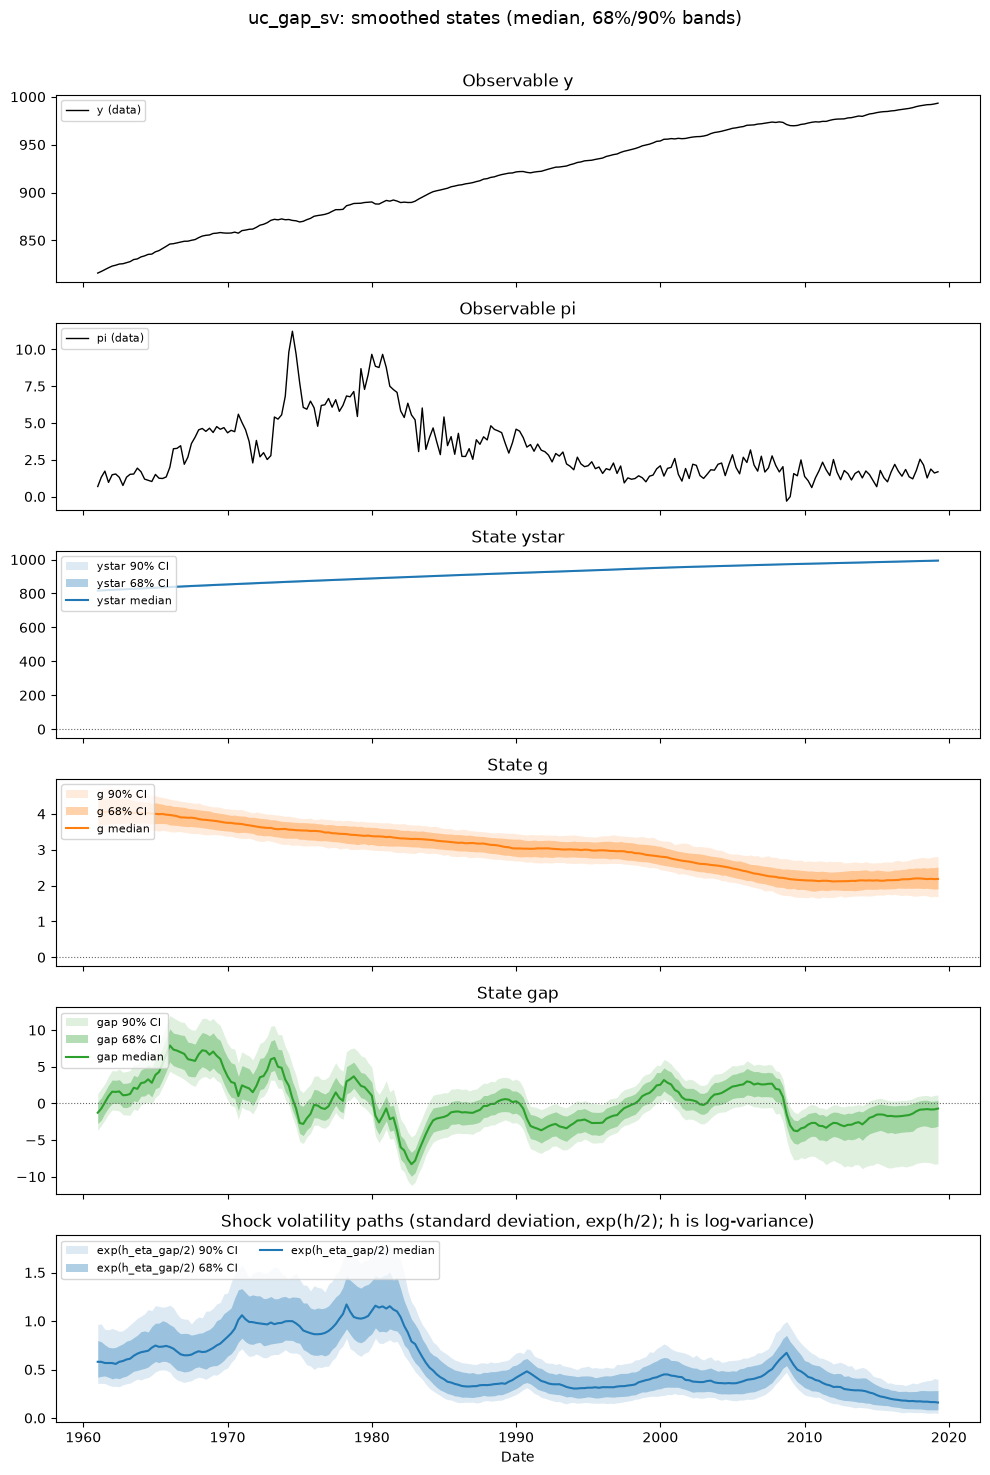

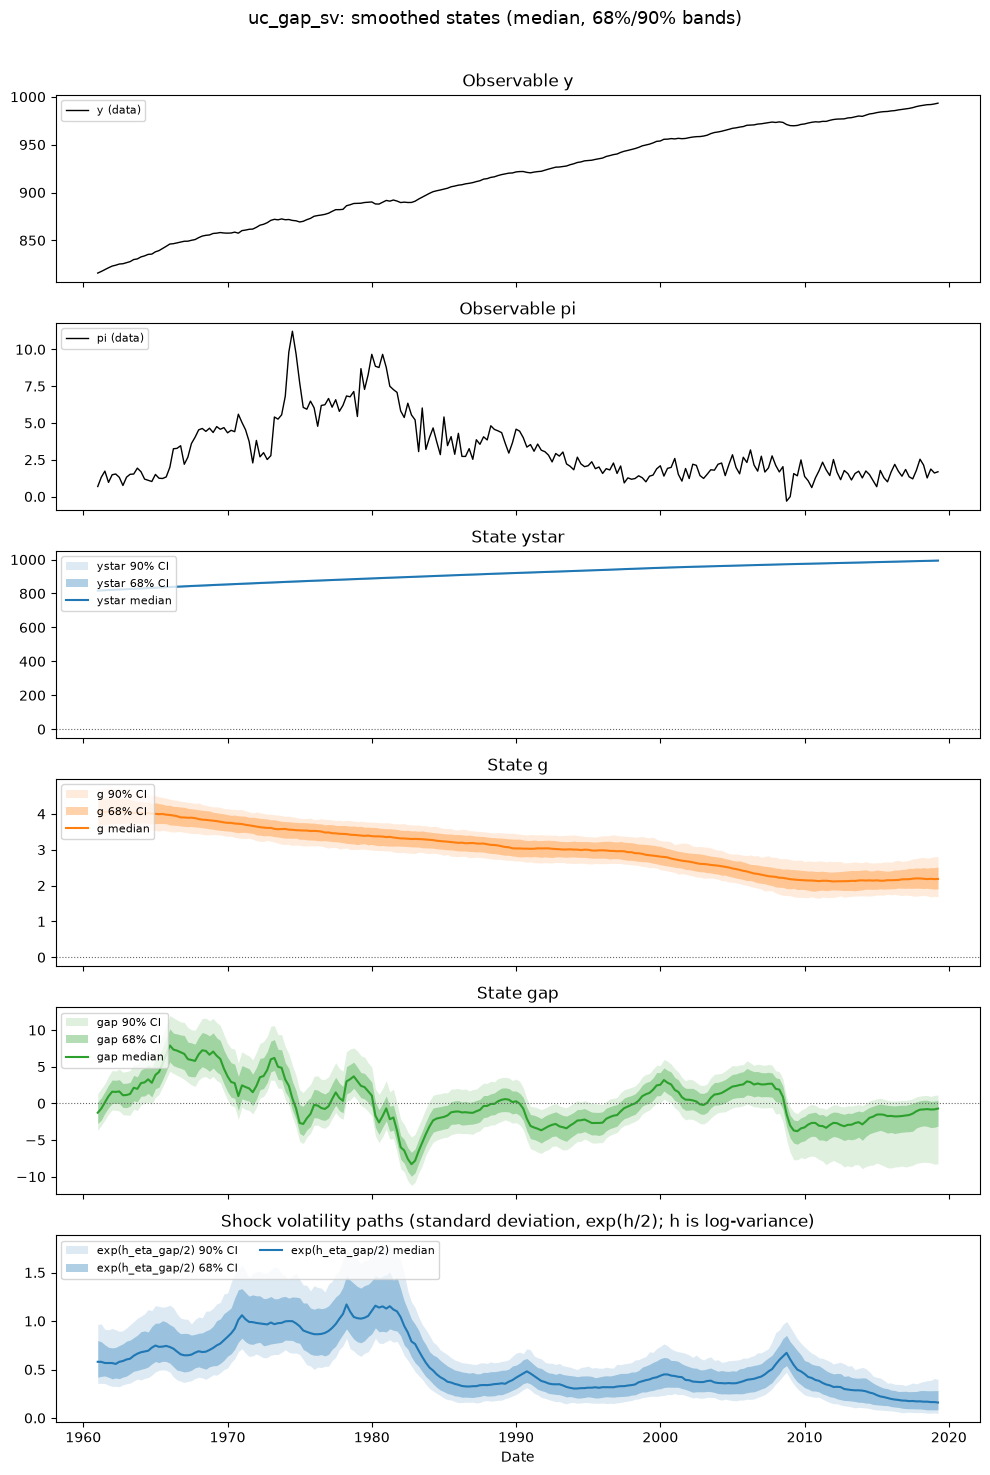

In [7]:
outs = run.outputs()
print(outs.names)
outs.figure("states")

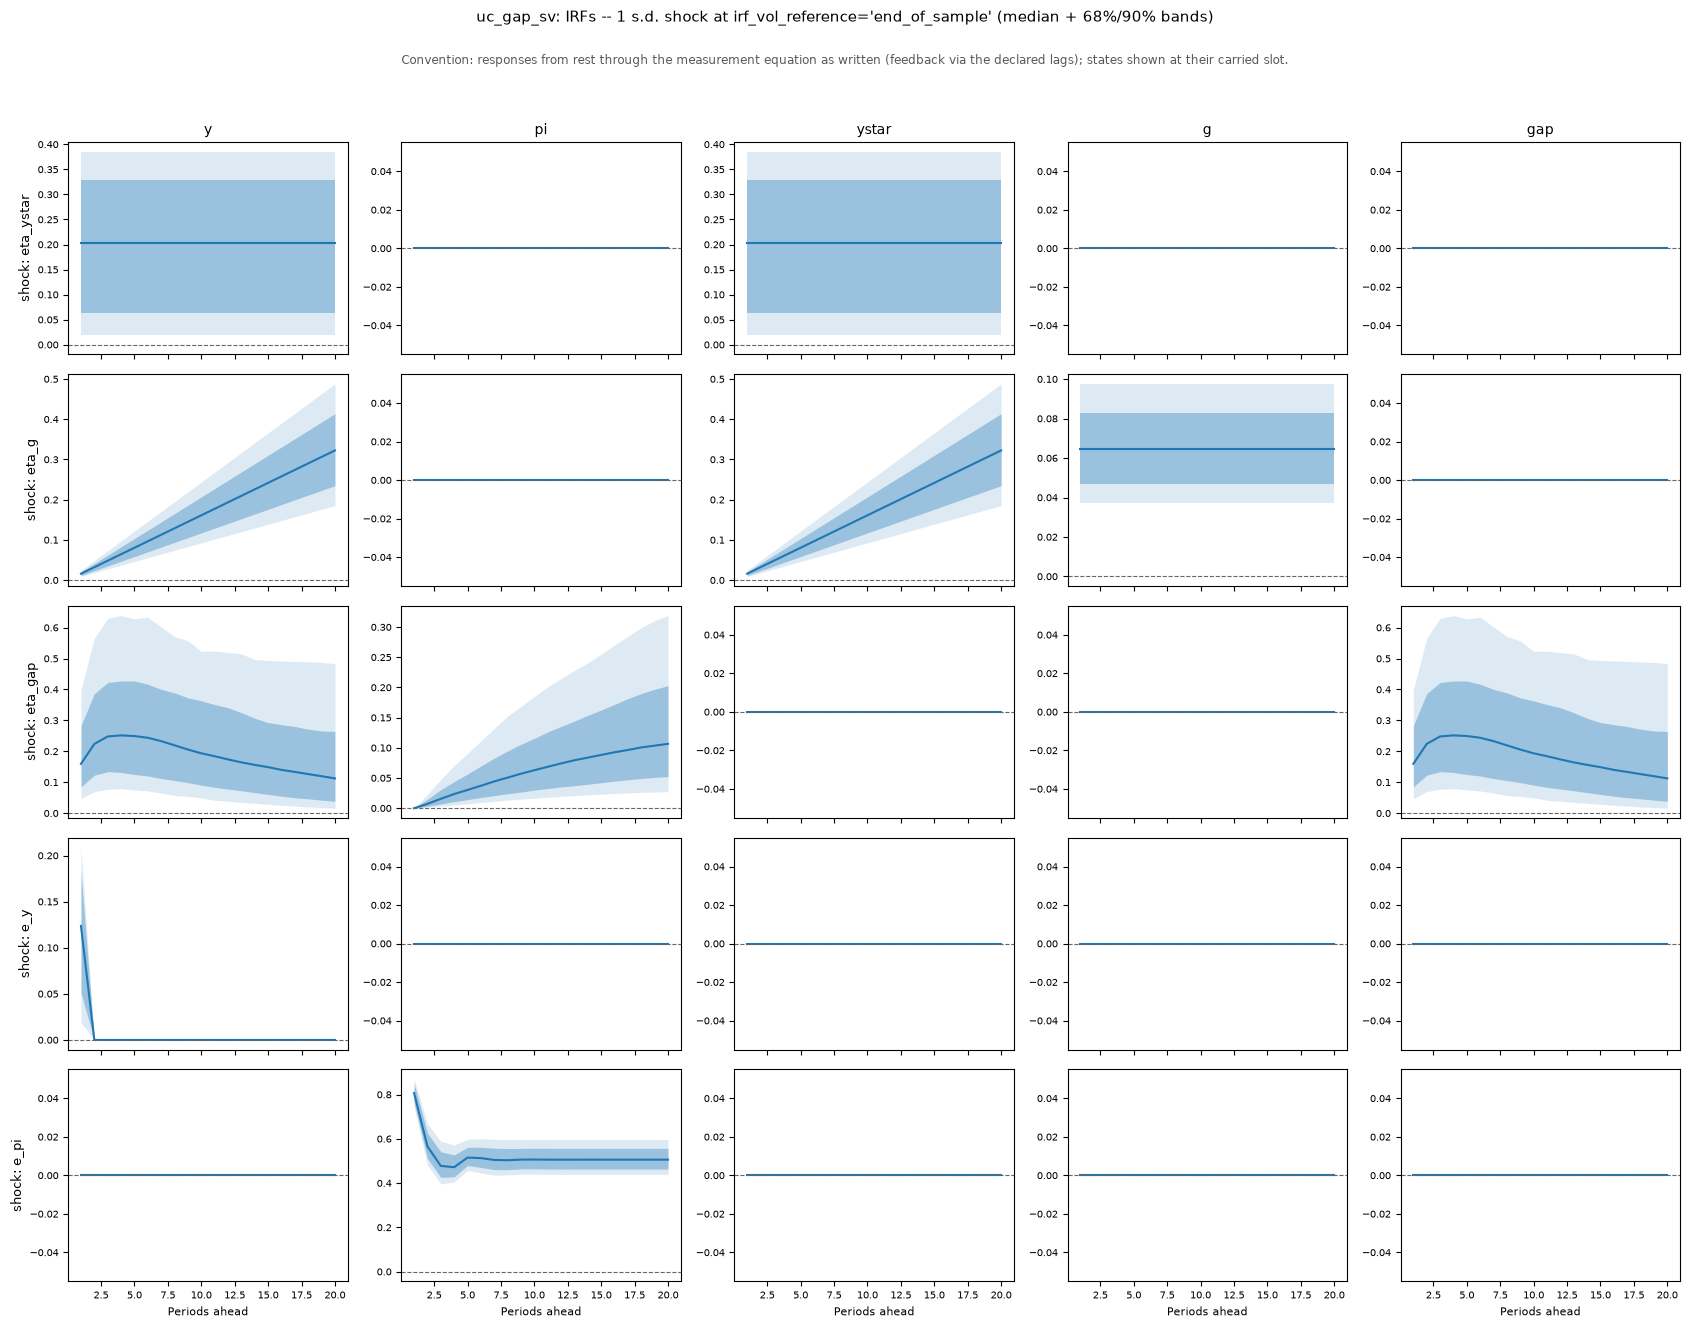

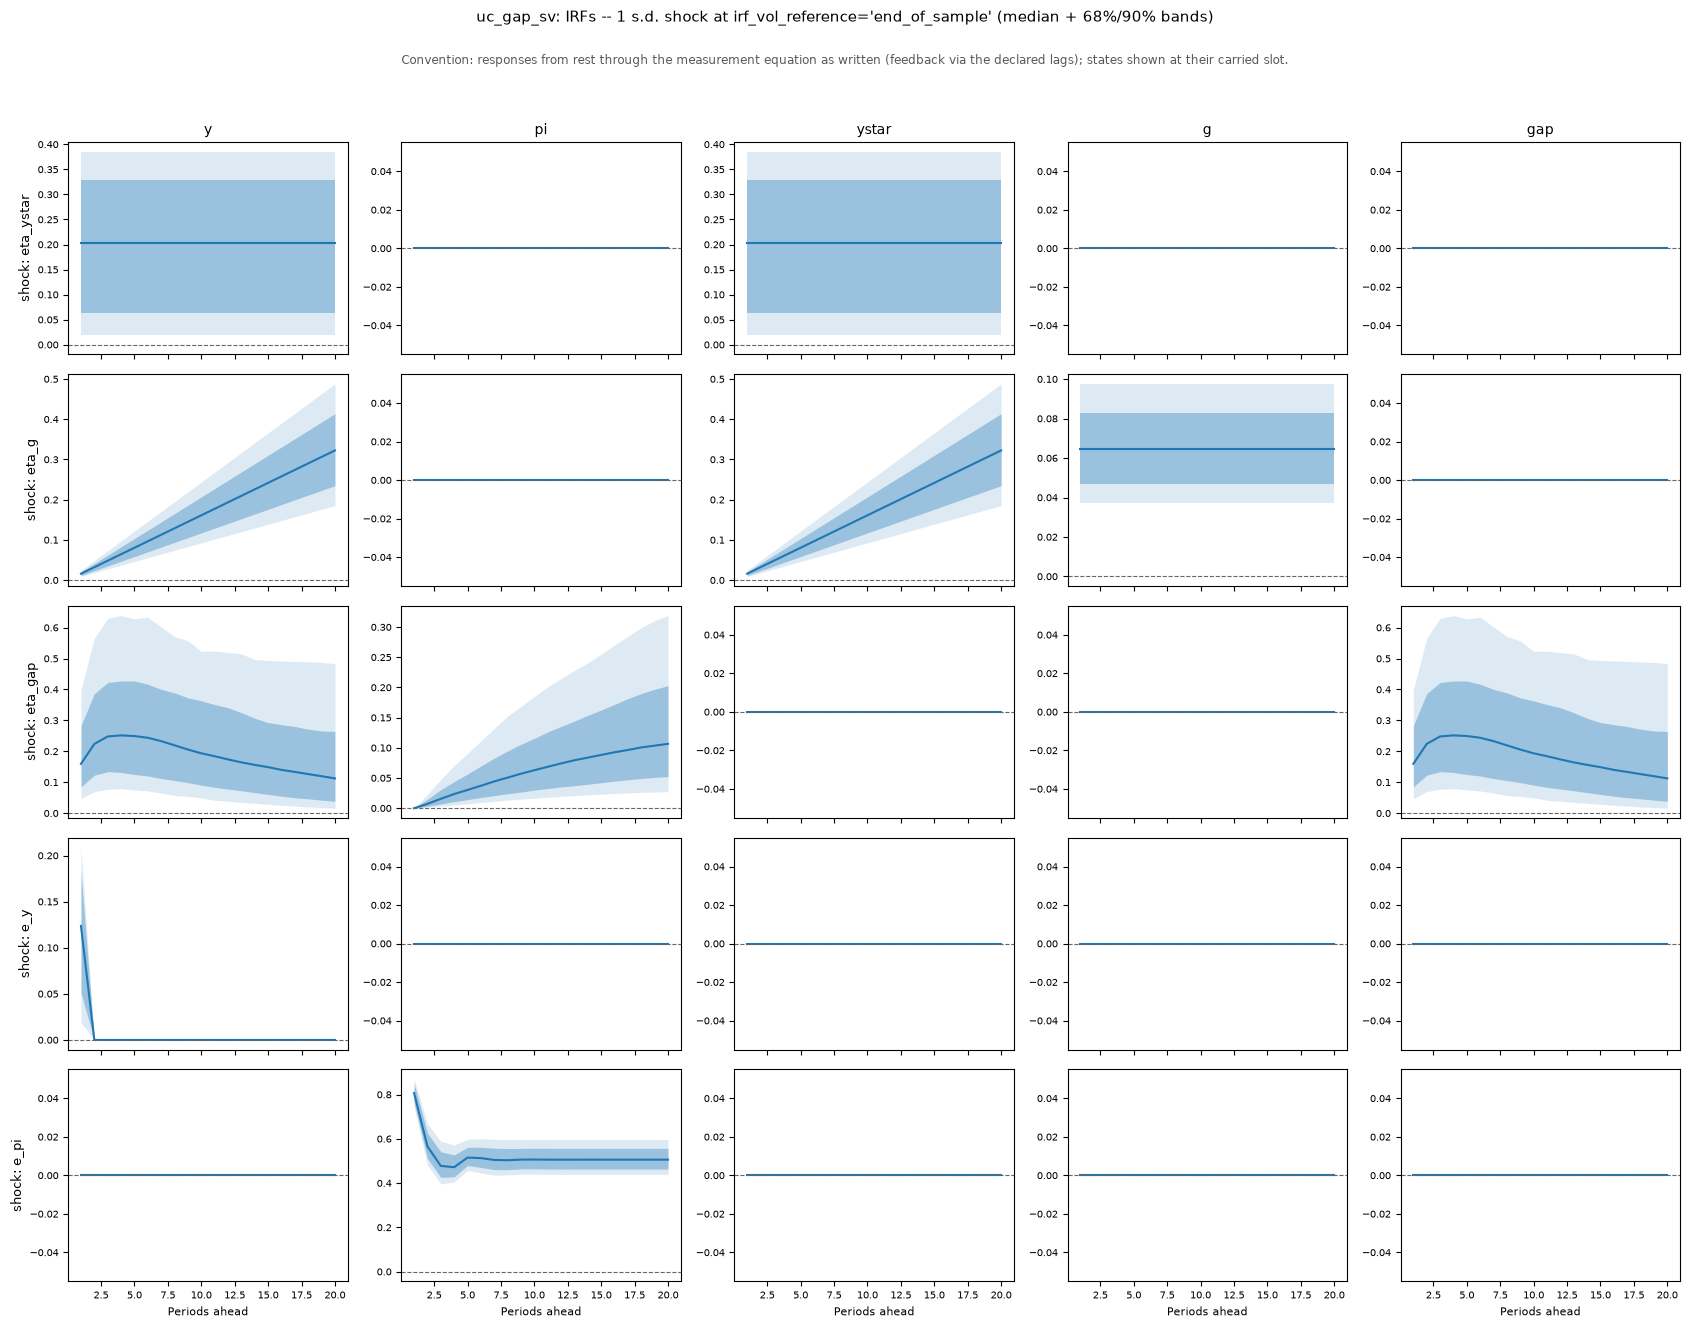

In [8]:
outs.figure("irf")

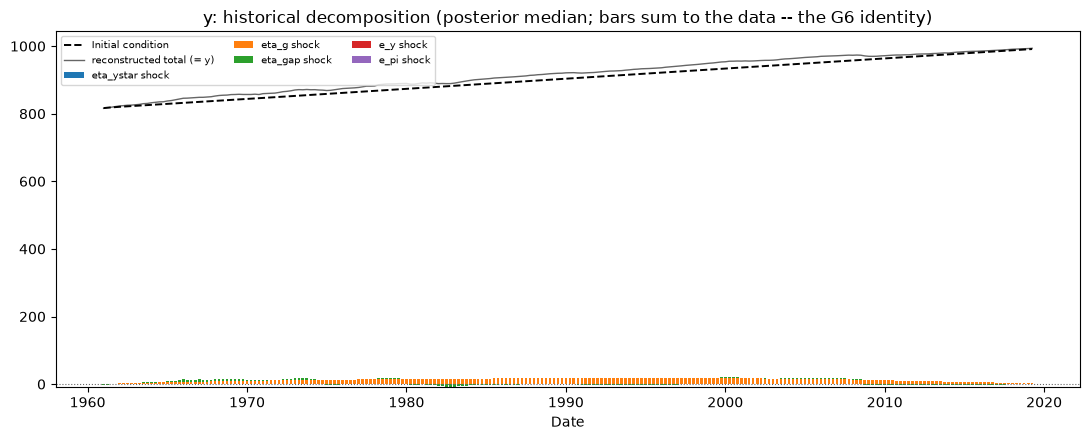

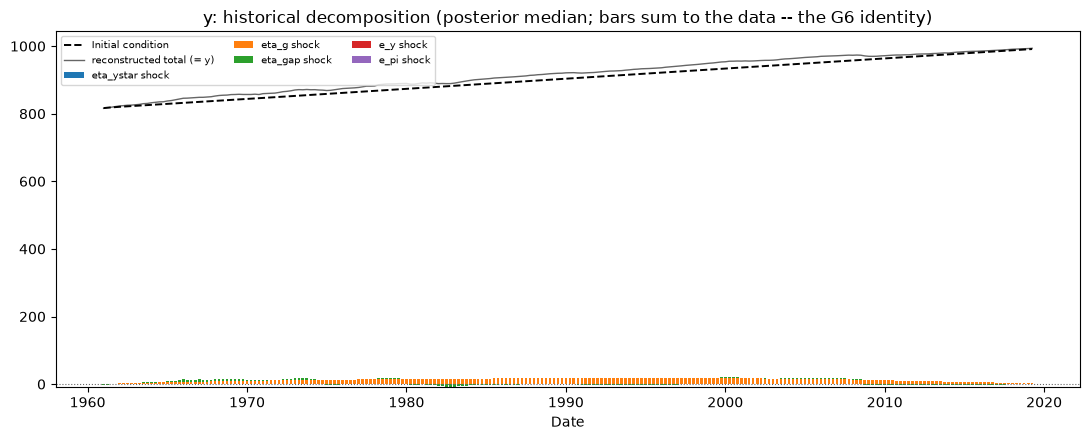

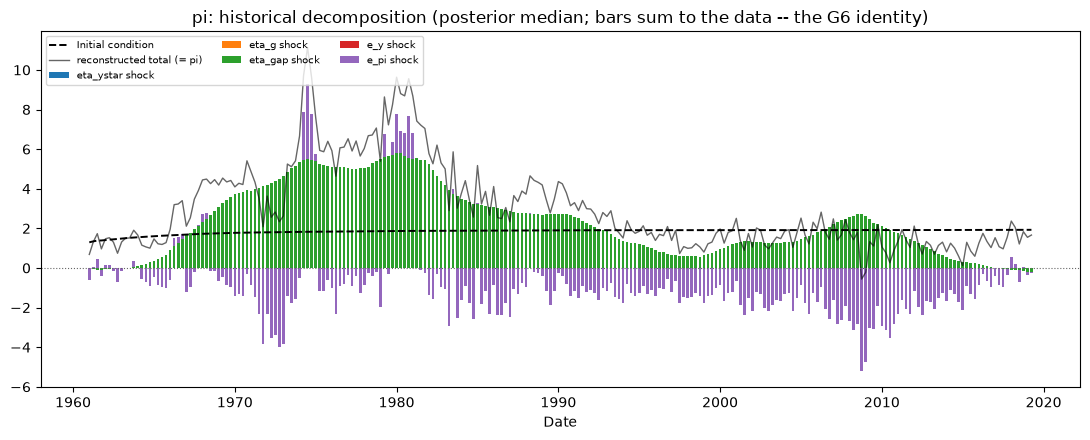

In [9]:
outs.figure("hd")["y"]

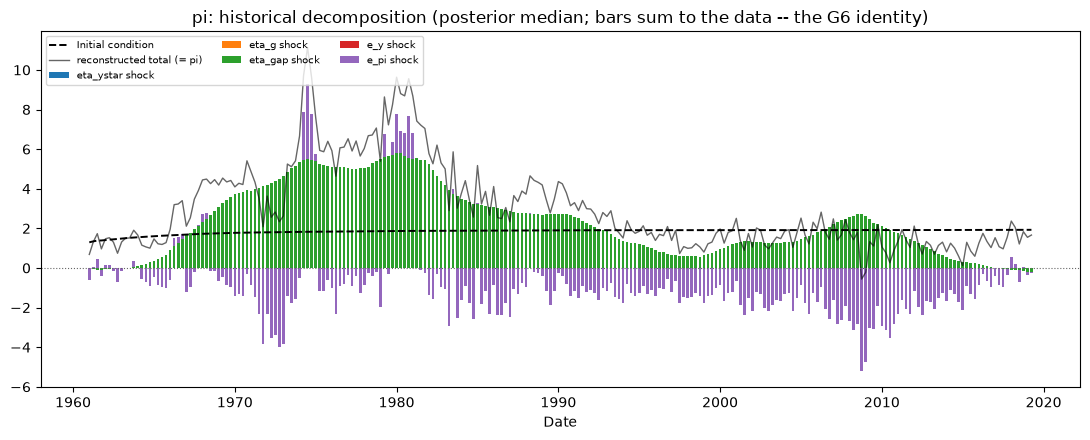

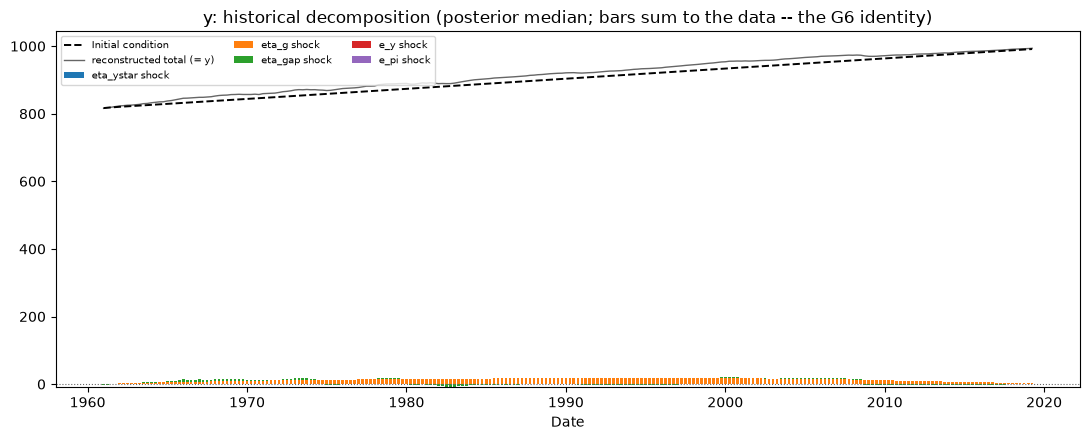

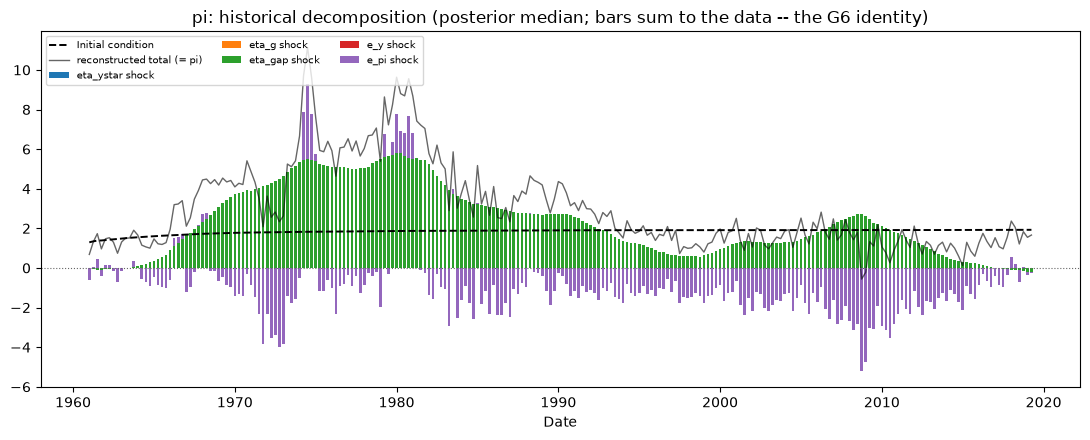

In [10]:
outs.figure("hd")["pi"]

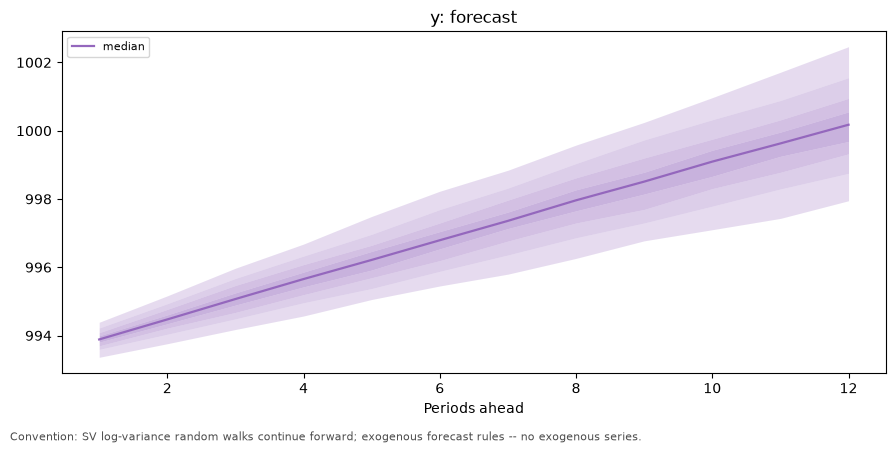

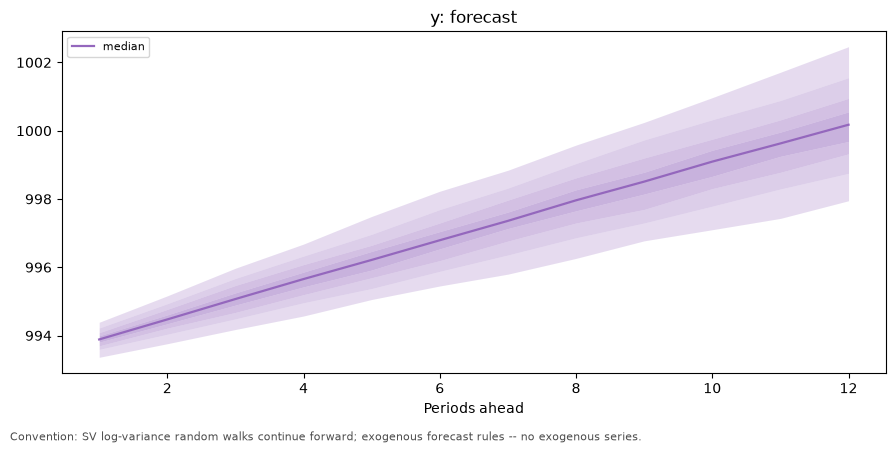

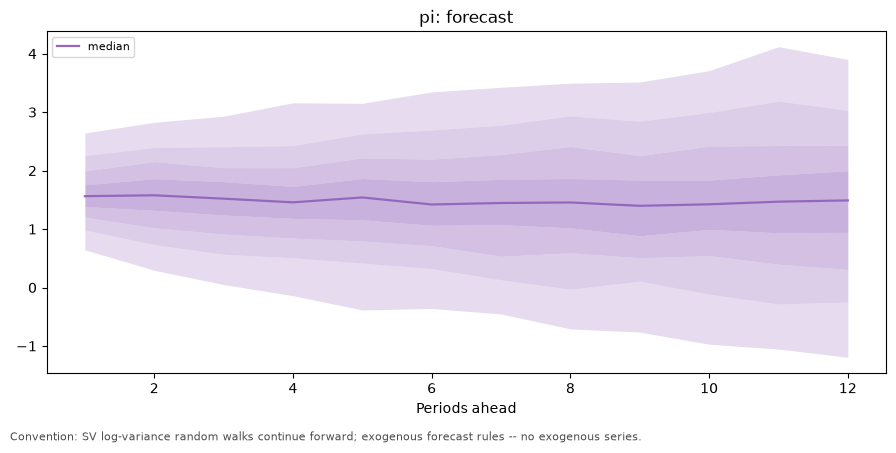

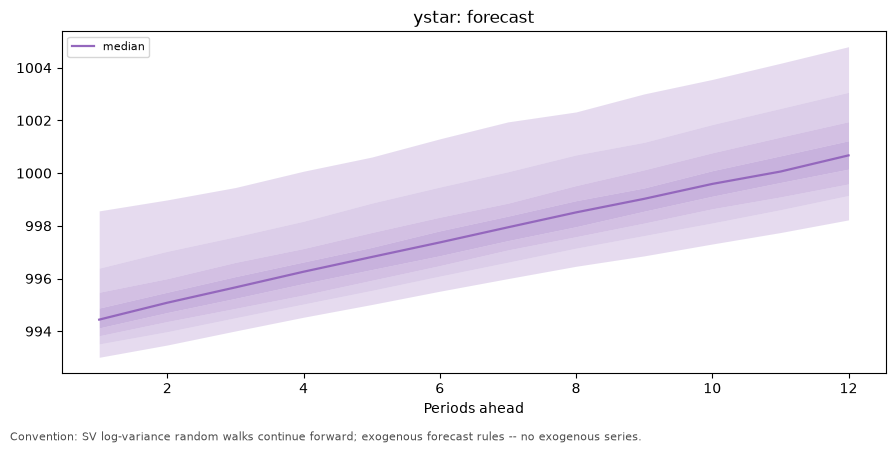

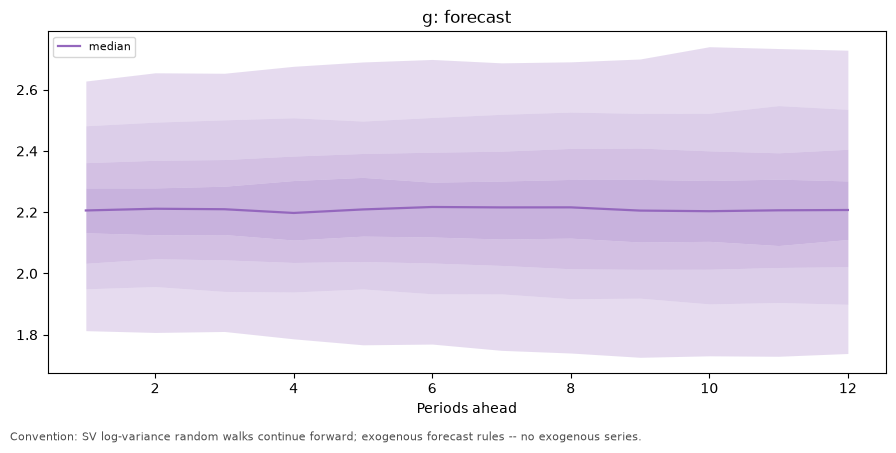

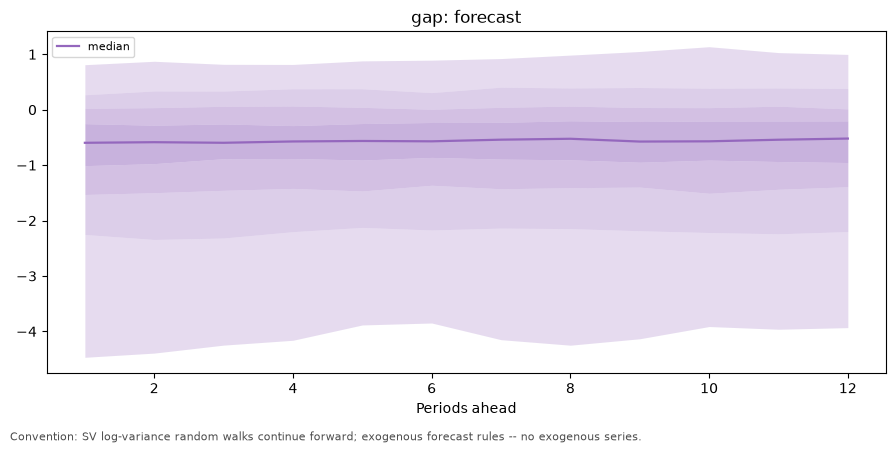

In [11]:
fans = outs.figure("fan")
fans["y"]

In [12]:
hdd = outs.compute("hd")
for o in ("y", "pi"):
    total = sum(hdd.obs[o][b] for b in hdd.bars)
    print(f"{o}: max |sum of bars - data| = {np.max(np.abs(total - run.results().yobs[:, list(compiled.meta.obs_names).index(o)][None, :])):.2e}")

y: max |sum of bars - data| = 3.41e-13
pi: max |sum of bars - data| = 1.89e-13


## 4. Sweep a prior

`sigma_g` is a boundary-prone random-walk scale doing identification work
(the pile-up problem lw_sv documents), so its sensitivity is measured, not
asserted: `mtk.sweep` runs halved/doubled prior scales as ordinary immutable
runs and reports the prior-to-posterior contraction per cell. (Two extra
fits; each cell is idempotent.)

In [13]:
sweep = mtk.sweep(
    {"name": "uc_gap_sigma_g", "cells": [
        {"label": "sigma_g_tight", "priors": {"sigma_g": {"sd": 0.015}}},
        {"label": "baseline", "priors": {}},
        {"label": "sigma_g_loose", "priors": {"sigma_g": {"sd": 0.06}}},
    ]},
    base_spec=spec, base_dir=DATA.parents[1],
)
tbl = sweep.comparison.table()
tbl[tbl["parameter"] == "sigma_g"][["cell", "median", "lo", "hi", "prior_sd", "posterior_sd", "contraction"]].round(4)

,cell,median,lo,hi,prior_sd,posterior_sd,contraction
0,sigma_g_tight,0.0237,0.0017,0.0513,0.0090,0.0165,-2.3309
1,baseline,0.0630,0.0370,0.0970,0.0180,0.0185,-0.0573
2,sigma_g_loose,0.1061,0.0568,0.1784,0.0361,0.0377,-0.0898


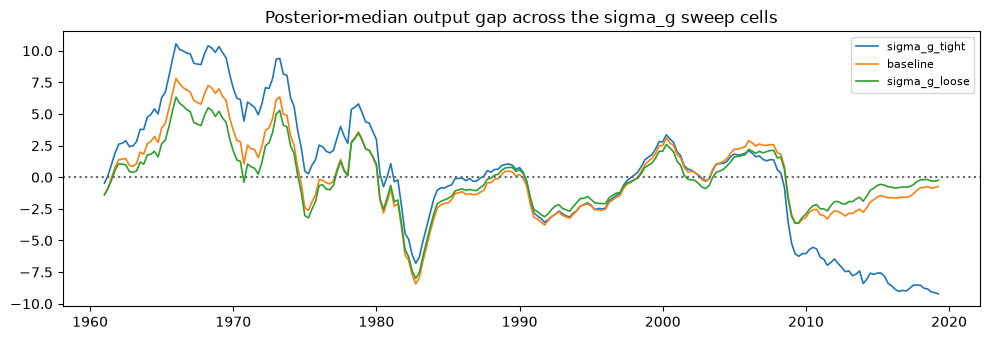

In [14]:
fig, ax = plt.subplots(figsize=(10, 3.5))
for label, series in sweep.comparison.headline.items():
    dates, med = series["gap"]
    ax.plot(dates, med, linewidth=1.2, label=label)
ax.axhline(0, color="0.4", linestyle=":")
ax.set_title("Posterior-median output gap across the sigma_g sweep cells")
ax.legend(fontsize=8)
fig.tight_layout()
fig

## 5. The fast validation tier, auto-instantiated

`mtk validate` takes the spec of an authored model and runs the first rungs
of the ladder for it: the Stan-vs-Python mirror gate at 25 prior draws of the
production render, and the historical-decomposition identity at stationary
prior points. The recovery and SBC rungs are one-call constructors
(`macrotoolkit.authoring.validation.recovery_design` / `sbc_design`) --
pre-registering and running them is per-model work, deliberately not done
here.

In [15]:
result = mtk.validate(spec, tier="fast", data=df)   # the DataFrame stands in for data.file
for g in result.gates:
    print(f"{g.name:12s} {g.verdict}  {g.summary}")
print("report:", result.report_path.name)

mirror       PASS  max |Stan - Python| KF loglik = 7.276e-11 over 25 prior draws (gate 1e-08)
hd_identity  PASS  historical-decomposition reconstruction: max |error| = 2.27e-13 over 5 simulation-smoother draws (gate 1e-06)
report: report.html


## 6. Report

`run.report()` writes the self-contained `report.html` with every module
above; the same estimation is reproducible from a YAML file carrying the
canonical equations (`spec.to_canonical_yaml()`), through `mtk run`.

In [16]:
path = run.report()
print(path.name, path.stat().st_size // 1024, "KB;", path.read_text().count("<img "), "embedded figures")
plt.close("all")

report.html 943 KB; 10 embedded figures
